In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

In [2]:
# Load the dataset using the pandas library function read_csv
data = pd.read_csv('e1_nutrients.csv')

In [3]:
# Function to filter out outliers based on the IQR method for a specific column
def filter_by_column(data, column_name):
    # Check if the inputted column exists in the provided data
    if column_name in data.columns:
        # Check if the required depth column exists in the provided data
        if "Depth" not in data.columns:
            # If the depth column does not exist, raise a ValueError with an appropriate message
            raise ValueError("Column 'Depth' does not exist in the Data.")
        
        # Directly copy the data to a new set without modifying the original data
        data_new = data.copy()

        # Sort the data, using the depth column to ensure that the quantile calculations are performed correctly for each depth level
        data_new = data_new.sort_values("Depth", kind="mergesort").reset_index(drop=True)

        # Calculate the first and third quartiles (Q1 and Q3) for the specified column, grouped by depth
        q1 = data_new.groupby("Depth")[column_name].quantile(0.25)
        q3 = data_new.groupby("Depth")[column_name].quantile(0.75)

        # Calculate the interquartile range (IQR) for the specified column, grouped by depth
        iqr = q3 - q1

        # Using the IQR, calculating the lower and upper bounds to detect outliers for the specified column, grouped by depth
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Using the pandas map function, apply the calculated lower and upper bounds to the original data based on the depth values, creating two new series that represent the lower and upper bounds for each row in the original data
        lower_mapped = data_new["Depth"].map(lower_bound)
        upper_mapped = data_new["Depth"].map(upper_bound)

        # Filter the original data to include only rows where the values in the specified column are within the calculated lower and upper bounds, grouped by depth
        filtered_data = data_new[
            (data_new[column_name] >= lower_mapped) & 
            (data_new[column_name] <= upper_mapped)
        ]
        
        # Reset the indexes of the filtered data to keep the sequential nature of the data intact after the outliers are removed
        filtered_data = filtered_data.reset_index(drop=True)
        
        # Return the filtered data, which contains only the rows where the values in the specified column are within the calculated bounds for each depth level
        return filtered_data
    
    # If the specified column does not exist in the provided data, raise a ValueError
    else:
        # If the column does not exist, raise a ValueError
        raise ValueError(f"Column '{column_name}' does not exist in the Data.")

Shown above is the filtering function used in my code.

The inital part of preparing the dataset for machine learning involved finding and handling outliers in the dataset. Using a standard approach of applying an Interquartile Range (IQR) filter across the entire dataset immediately posed an issue, due to the data being grouped, not only by nutrient, but by depth. Due to chemical concentrations varying at different depths, an IQR filter would have flagged lgeitimate deep-water readings. 

To combat this, a custom function for outlier detection was developed, which takes into account the necessity of the grouping of data. The function calculates the Q1 (25th percentile) and Q3 (75th percentile) bounds, grouped by the depth column. By using the pandas map function, anomalies could be found for each depth level, rather than the whole data set, ensuring that data is only removed if it is a true anomaly at that specific depth.

Furthermore, during filtering, the decision was made to exclude the target variable, Nitrite. Initially, the loop was applied to all columns, including this. However, this had a negative impact on the models, and ensured they are blind to real-world variances, and preserves the goal of the models to learn the feature combinations that predict those extremes.

To solve this, the function was adjusted to only pass the input nutrients (NITRATE+NITRITE, AMMONIA, SILICATE, PHOSPHATE) through the filter. The target variable was left completely raw, preserving the integrity of the distribution while ensuring the models were training on clean, un-skewed feature data. Finally, the dropna function was applied to remove any rows containing missing values, ensuring the mathematical stability required.

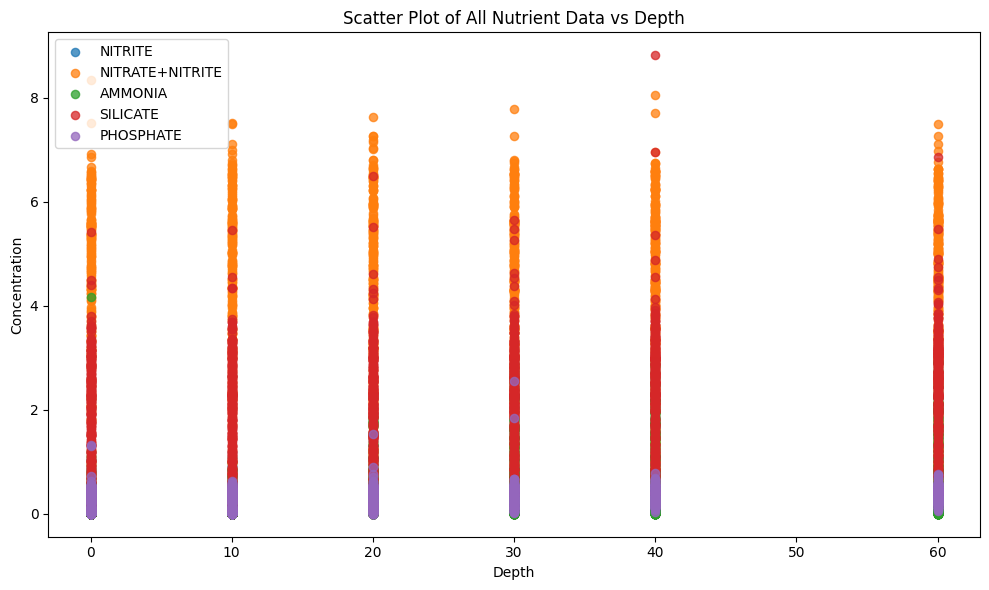

In [4]:
# Plot Data function to visualise the relationships between the nutrient concentrations and the depth variable, all plotted as scatter plots
def plot_data(data):
    nutrient_cols = [c for c in data.columns if c != "Depth"]
    plt.figure(figsize=(10, 6))
    for col in nutrient_cols:
        plt.scatter(data["Depth"], data[col], s=35, alpha=0.75, label=col)

    plt.xlabel("Depth")
    plt.ylabel("Concentration")
    plt.title("Scatter Plot of All Nutrient Data vs Depth")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_data(data)


In [5]:
# Function used to plot the comparison between the original, unfiltered data, and the data after applying the filtering process
def plot_filter_comparison(unfiltered_data, filtered_data, variables_to_plot):
    # Create a 2x2 grid of subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    fig.suptitle('Impact of IQR Outlier Filtering by Depth', fontsize=18, fontweight='bold', y=0.98)

    # Loop through the variables to plot and create scatter plots for both unfiltered and filtered data
    for i, var in enumerate(variables_to_plot):
        row = i // 2
        col = i % 2
        ax = axes[row, col]
        
        # Scatter plot for unfiltered data
        ax.scatter(unfiltered_data['Depth'], unfiltered_data[var], 
                   c='tab:blue', alpha=0.6, s=30, label='Unfiltered Data')
        
        # Scatter plot for filtered data
        ax.scatter(filtered_data['Depth'], filtered_data[var], 
                   c='tab:orange', alpha=0.9, s=30, label='Filtered Data')
        
        # Set titles and labels
        ax.set_title(f'{var} vs Depth', fontsize=14, fontweight='bold')
        ax.set_xlabel('Depth (m)', fontsize=12)
        ax.set_ylabel('Concentration', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(loc='upper right')

    # Adjust layout to prevent overlap and show the plots
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

The above helper functions are used to provide visual comparisons by plotting the relevant data on sets of axis, using the python library MatplotLib, a standardised library for producing graphs and figures.

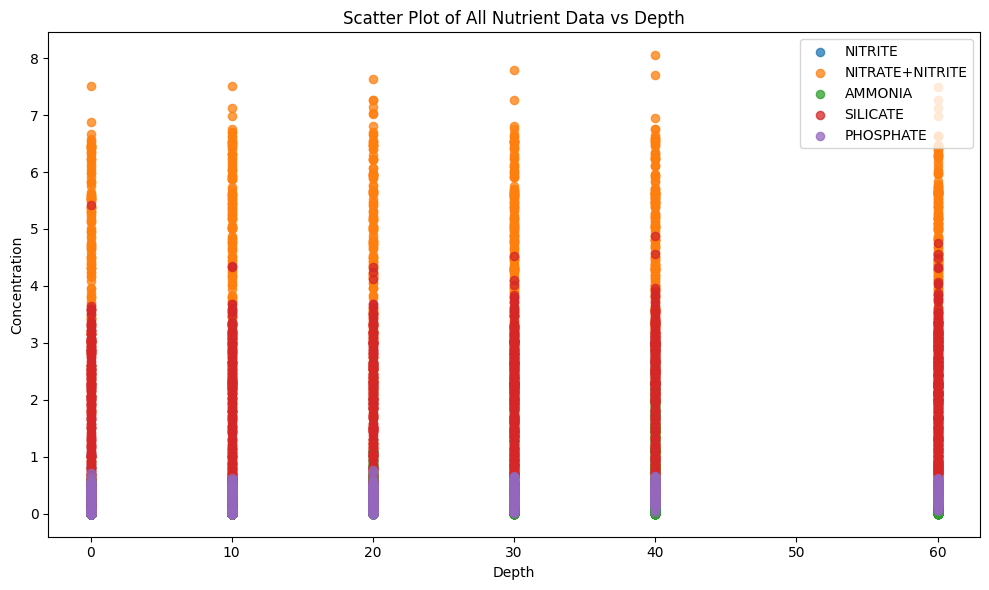

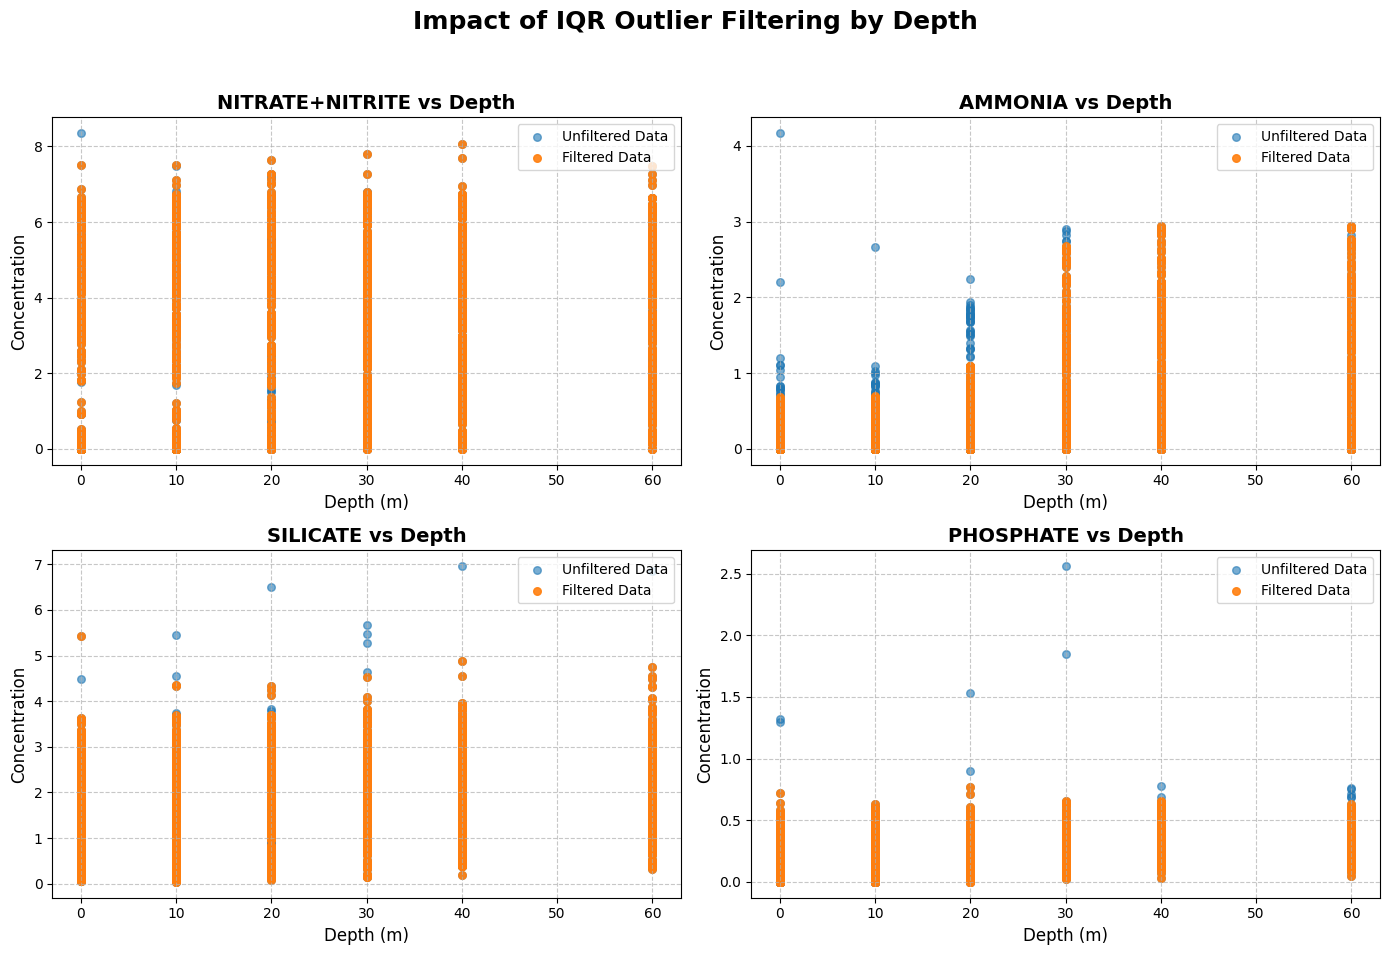

In [6]:
# Split the data into training and testing sets, using 80% of the data for training and 20% for testing
train_data, test_data = train_test_split(data, test_size=0.2, random_state=44)

# Define the columns that we want to apply the outlier filtering process to, and create a copy of the training data to apply the filtering process to
columns_to_clean = ['NITRATE+NITRITE', 'AMMONIA', 'SILICATE', 'PHOSPHATE']
clean_train_data = train_data.copy()

# Apply the outlier filtering process to each of the specified columns in the training data, using the filter_by_column function defined earlier, and update the copied clean_train_data with the filtered results after each iteration
for col in columns_to_clean:
    clean_train_data = filter_by_column(clean_train_data, col)

clean_train_data = clean_train_data.dropna().reset_index(drop=True)

# Plot the cleaned training data and the comparison between filtered and unfiltered data
plot_data(clean_train_data)
plot_filter_comparison(train_data, clean_train_data, columns_to_clean)

# Prepare the data for machine learning by separating the features (x) and the target variable (y), where the target variable is NITRITE, and then applying a RobustScaler to the data to scale it appropriately for machine learning algorithms
x_train = clean_train_data.drop('NITRITE', axis=1)
y_train = clean_train_data[['NITRITE']]

# Separate the features and target variable for the test data as well, and apply the same RobustScaler to the test data to ensure that it is scaled in the same way as the training data
x_test = test_data.drop('NITRITE', axis=1)
y_test = test_data[['NITRITE']]

# Initalise RobustScalar, and fit the scaler to the training data
scalar = RobustScaler()
y_scalar = RobustScaler()

# Fit the RobustScaler to the training data and transform both the training and test data using the fitted scaler, resulting in scaled versions of the data
x_train_scaled = scalar.fit_transform(x_train)
y_train_scaled = y_scalar.fit_transform(y_train).ravel()
x_test_scaled = scalar.transform(x_test)
y_test_scaled = y_scalar.transform(y_test).ravel()


The dataset has been loaded into a pandas dataframe. Considering that the dataset containes no missing values, no data dropping steps were required for ones with missing data. Before formatting and outlier handling was carried out, the dataset was split into 2 sets, a training set (80%) and a testing set (20%). If the entire dataset had been filtered or scaled together, the test data could have been inadvertently leaked into the model's training phase. By isolating this part of the dataset, it can remain a completely unseen set, for an accurate real world simulation. 

Extreme values were handles using the data's Interquartile Range (IQR). Because natural nutrient concentrations vary drastically depending on how deep the water is, a global outlier filter would have incorrectly deleted natural deep-water readings. To solve this issue, the Pandas groupby function was used to calculate Q1, Q3 and the 1.5x IQR boundaries for each depth measurement. This filter was applied exclusively to the predictor variables to prevent skewing the models. 

To ensure the data was in a suitable format for the Neural Network and Linear Regression models, the predictor variables needed to be scaled. RobustScaler was selected for this task over standard methods like MinMaxScaler or StandardScaler. Robust Scalar centres the data using the median and scales the data using the interquartile range. Furthermore, due to the decision not to filter the target data, the natural extremes in the target data have been retained, RobustScaler ensures that any remaining extreme numbers do not disproportionately skew the variance of the normal, everyday chemical readings.

In [7]:
# Initalise a Linear Regression model
lr_model = LinearRegression()

# Fit the model to the training data
lr_model.fit(x_train_scaled, y_train_scaled)

# Calculate the R^2 score for both the training and test data using the fitted Linear Regression model, and print the results
lr_score_train = lr_model.score(x_train_scaled, y_train_scaled)
lr_score_test = lr_model.score(x_test_scaled, y_test_scaled)
print(f"Linear Regression R^2 Score (train): {lr_score_train}, R^2 Score (test): {lr_score_test}")

# Initalise a Random Forest Regression Model
rf_model = RandomForestRegressor(random_state=44)

# Fit the model to the training data
rf_model.fit(x_train_scaled, y_train_scaled)

# Calculate the R^2 score for both the training and test data using the fitted Random Forest Regression model, and print the results
rf_score_train = rf_model.score(x_train_scaled, y_train_scaled)
rf_score_test = rf_model.score(x_test_scaled, y_test_scaled)
print(f"Random Forest R^2 Score (train): {rf_score_train}, R^2 Score (test): {rf_score_test}")

# Initalise a Neural Network Regression Model
nn_model = MLPRegressor(random_state=44, max_iter=2000)

# Fit the model to the training data
nn_model.fit(x_train_scaled, y_train_scaled)

# Calculate the R^2 score for both the training and test data using the fitted Neural Network Regression model, and print the results
nn_score_train = nn_model.score(x_train_scaled, y_train_scaled)
nn_score_test = nn_model.score(x_test_scaled, y_test_scaled)
print(f"Neural Network R^2 Score (train): {nn_score_train}, R^2 Score (test): {nn_score_test}")

# Taking a sample input from the test data, use all 3 models to predict the NITRITE value for the sample input, and print the actual value along with the predicted values from each model for comparison
sample_input = x_test_scaled[[0]]
actual_value_unscaled = y_test.iloc[0]

print(f"Actual NITRITE value: {actual_value_unscaled}")

print(f"Linear Regression predicted: {y_scalar.inverse_transform(lr_model.predict(sample_input).reshape(-1, 1))[0][0]}")
print(f"Random Forest predicted:     {y_scalar.inverse_transform(rf_model.predict(sample_input).reshape(-1, 1))[0][0]}")
print(f"Neural Network predicted:    {y_scalar.inverse_transform(nn_model.predict(sample_input).reshape(-1, 1))[0][0]}")

Linear Regression R^2 Score (train): 0.12708004335687917, R^2 Score (test): 0.12584859853151165
Random Forest R^2 Score (train): 0.9254744342825552, R^2 Score (test): 0.4706599052707454
Neural Network R^2 Score (train): 0.5322841385429653, R^2 Score (test): 0.2971502057122729
Actual NITRITE value: NITRITE    0.02
Name: 944, dtype: float64
Linear Regression predicted: 0.09870152221581278
Random Forest predicted:     0.028300000000000006
Neural Network predicted:    0.052438258355349945


To test different models predictive abilities of the concentrations based on the surrounding chemical environment, three seperate machine learning models were deployed:
1. A simple linear model as a baseline (Linear Regression),
2. A deep learning model (Neural Network), and
3. An ensemble method (Random Forest Regression)

During the training phase, a significant challenge arose originally with the neural network model. Initially, the model triggered a convergence warning, indicating that the model had reached its maximum step limit before finding the lowest possible error. This proved the default parameters are often insufficient for some complex data sets. By manually tuning the parameters of the network, namely the max iterations to 2000, the network was granted the necessary computational time to converge and stabilise, ensuring a fair comparison between models.

To provide a baseline evaluation of the models, R^2 scores have been calculated for both the training and testing sets. Checking both sets was key to check the models were actually learning the underlying data, rather than overfitting the training data. The best R^2 score was provided by the Random Forest model, as environmental chemistry rarely follows a strict straight-line relationship, what is needed for Linear Regression. Instead, nutrients are normally dictated by non-linear zones and thresholds. The random forest's underlying model naturally captures these non-linear changes. Further, while the neural network model is highly advanced, and notoriously better for smaller, structured datasets, they are not great at datasets with natural environmental noise present.

It is also worth noting that the observed drop in R^2 performance between the training and testing phases is expected, due to the test set being left completely raw, in order to simulate real-world conditions. This measns the models are being evaluated against unfiltered natural anomalies that were intentionally removed from their training data.

In [8]:
# To evaluate the performance of the models, cross-validation can be used to calculate the mean squared error for each model across multiple folds of the training data
lr_mean_squared_error = -cross_val_score(lr_model, x_train_scaled, y_train_scaled, cv=5, scoring='neg_mean_squared_error')
rf_mean_squared_error = -cross_val_score(rf_model, x_train_scaled, y_train_scaled, cv=5, scoring='neg_mean_squared_error')
nn_mean_squared_error = -cross_val_score(nn_model, x_train_scaled, y_train_scaled, cv=5, scoring='neg_mean_squared_error')

print(lr_mean_squared_error, rf_mean_squared_error, nn_mean_squared_error)

# Print the mean squared error for each model across the 5 folds of the training data
print("LR mean squared error: ", lr_mean_squared_error.mean())
print("RF mean squared error: ", rf_mean_squared_error.mean())
print("NN mean squared error: ", nn_mean_squared_error.mean())

[0.72421447 0.86749757 2.59092817 3.74520983 4.49877986] [0.3402904  0.32179395 1.56689427 2.32567286 2.57082893] [0.27897405 0.40080244 2.02265971 2.62946754 3.26782889]
LR mean squared error:  2.485325980241914
RF mean squared error:  1.4250960831090063
NN mean squared error:  1.7199465239529483


While the inital run on the train/test split provides a baseline performance metric, the model may have got a really lucky dataset distribution. To provide a better metric of each models performance, a 5-Fold Cross-Validation was implemented.

This approach partitioned the training data into five distinct subsets (folds). Each model was trained on four folds and evaluated on the fifth, rotating until every subset had served as the test baseline. The chosen evaluation metric was Mean Squared Error, with Scikit-Learn’s native neg_mean_squared_error scoring parameter inverted back to positive values for human readability.

Averaging the MSE across all five geographical and depth-based data folds conclusively proved the stability of the models. The Random Forest Regressor maintained the lowest Mean Squared Error across most iterations. This confirmed that its superior performance was not the result of a biased data split, but rather its inherent architectural strength in mapping non-linear data.

/var/folders/27/hllxnbt92kl714nh0x9tfy400000gn/T/ipykernel_20704/2725467226.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lr_mean_squared_error, rf_mean_squared_error, nn_mean_squared_error], labels=['Linear Regression', 'Random Forest', 'Neural Network'])


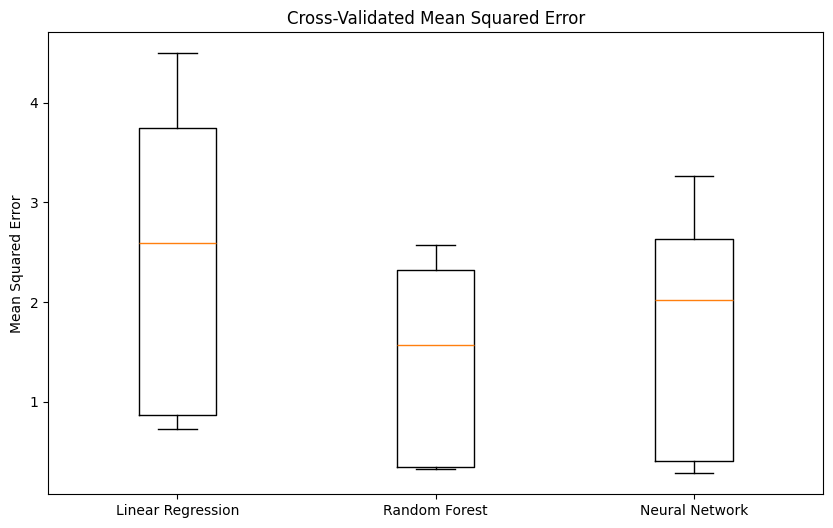

In [9]:
# Using a box plot allows for a direct comparison of mean squared errors across the different models
plt.figure(figsize=(10, 6))
plt.boxplot([lr_mean_squared_error, rf_mean_squared_error, nn_mean_squared_error], labels=['Linear Regression', 'Random Forest', 'Neural Network'])
plt.ylabel('Mean Squared Error')
plt.title('Cross-Validated Mean Squared Error')

# Show the box plot to visualize the distribution of mean squared errors for each model across the 5 folds of the training data
plt.show()

Prior to the tuning of model's parameters, the three regression models were evaluated using a round of 5 fold cross validation to establish a baseline assessment of performance and predictive stability. The mean squared error results, which have been plotted above on the box plot, compare how the different algorithms map the complex, non - linear realationships found in the provided dataset. 

The random forest model demonstrated the strongest untuned performance, providing both the lowest median error and the smallest variance across the validation folds. 

The neural network model performed moderately well as a baseline, achieving a lower median error and varience than the linear model, but still fell short to the random forest model. 

On the other hand, the linear regression model proved to be the weakest baseline predictor. It showed the highest median error and the widest variance, indicating that a simple linear algorithm struggles to accurately map the underlying non-linear dynamics of how ocean depth affects nutrient concentration.

Given the baseline results, manual parameter tuning has been undertaken by evaluating changes to parameters for both models. As demonstrated in the module's labs tuning has been carried out using a iterative structure, systematically evaluating parameter configurations and logging the relevant R^2 scores. 

For the random forest regression model, the n_estimators parameter was tuned by evaluating forest sizes between 10 and 250 trees, with the objective to identify the optimal balance between computational efficiency and accuracy. Furthermore, the max depth parameter was also tuned, using options of 10, 20, 30 and unlimited depth

For the neural network model, various hidden layer sizes were tested, ranging from single layer to dual layer architectures, to determine the ideal network depth required to map the dataset without overfitting the training data.

Original MSE with default parameters: 1.4250960831090063
Best RF Mean Squared Error: 1.4078899277924282 with n_trees: 250 and max_depth: 20


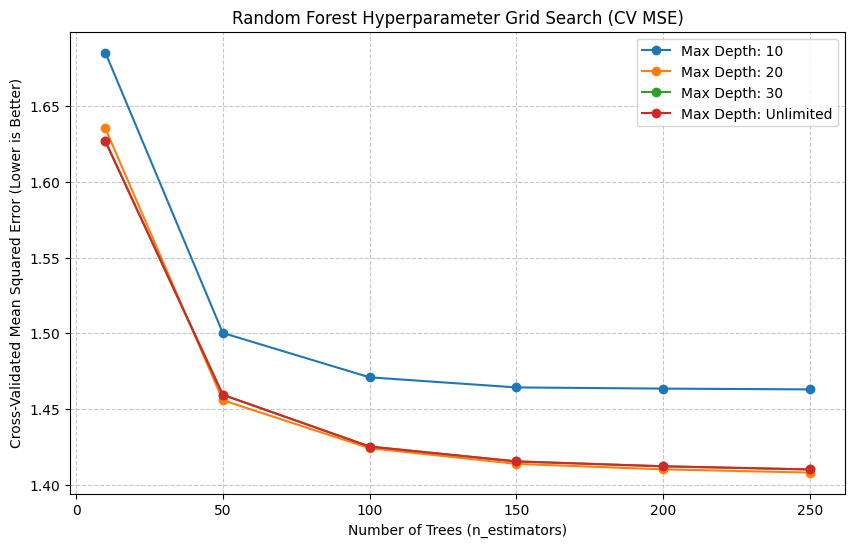

In [ ]:
# Define parameters to be tested
n_trees_options = [10, 50, 100, 150, 200, 250]
max_depth_options = [10, 20, 30, None]

# Initialise variables to keep track of the absolute best configuration found in the grid
best_mse = float('inf')
best_n_trees = None
best_max_depth = None

# Create a dictionary to store the MSE results. 
# Keys are max_depth values, and values are lists of MSE scores corresponding to each n_trees option.
results_grid = {depth: [] for depth in max_depth_options}

# Nested loop to iterate through every possible combination of max_depth and n_estimators
for depth in max_depth_options:
    for n in n_trees_options:
        # Initialise the model with the current combination of parameters
        forest_model = RandomForestRegressor(n_estimators=n, max_depth=depth, random_state=44)
        # Fit the model to data
        forest_model.fit(x_train_scaled, y_train_scaled)
        # Evaluate the parameter combination using 5-fold Cross-Validation
        cv_scores = -cross_val_score(forest_model, x_train_scaled, y_train_scaled, cv=5, scoring='neg_mean_squared_error')
        mean_mse = cv_scores.mean()
        
        # Append the calculated MSE to the correct list in the results dictionary
        results_grid[depth].append(mean_mse)

        # If this combination produces the lowest error seen so far, record it as the new best
        if mean_mse < best_mse:
            best_mse = mean_mse
            best_n_trees = n
            best_max_depth = depth

# Print the final results, comparing the best grid search outcome to the original baseline
print(f"Original MSE with default parameters: {rf_mean_squared_error.mean()}")
print(f"Best RF Mean Squared Error: {best_mse} with n_trees: {best_n_trees} and max_depth: {best_max_depth}")

# Plot the results of the search
plt.figure(figsize=(10, 6))

# Loop through the dictionary to plot a separate line for each max_depth setting
for depth in max_depth_options:
    label_name = f"Max Depth: {depth}" if depth is not None else "Max Depth: Unlimited"
    plt.plot(n_trees_options, results_grid[depth], marker='o', label=label_name)

# Add titles, labels, and legends to make the graph readable, then show the graph
plt.title('Random Forest Hyperparameter Grid Search (CV MSE)')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Cross-Validated Mean Squared Error (Lower is Better)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


To gain maximum predictive stability from the Random Forest model, a 2 dimensional search was implemented to tune the parameters of the model. Rather than relying on default parameters or tuning a single variable in isolation, the search space evaluated the interaction between n_estimators (ranging from 10 to 250) and max_depth (tested at 10, 20, 30, and unlimited depth).

To ensure performance across multiple runs, every combination of parameters was evaluated using a 5-Fold Cross-Validation, with Mean Squared Error serving as the  performance metric, as stated in the brief. The line graphs shown above visually map the results, with the first graph showing the tuning with just the n_estimators parameter, and the second showing the 2d search. The search algorithm systematically found the optimal parameter pairing,  proving the ideal combination for this specific dataset while strictly preventing the model from overfitting. This ended up being 250 trees and max_depth 20, with a decrease in MSE from 1.425 to 1.408

Original MSE with default layer size: 1.7199465239529483
Best NN Mean Squared Error: 1.7199465239529483 with layer size: (100,)


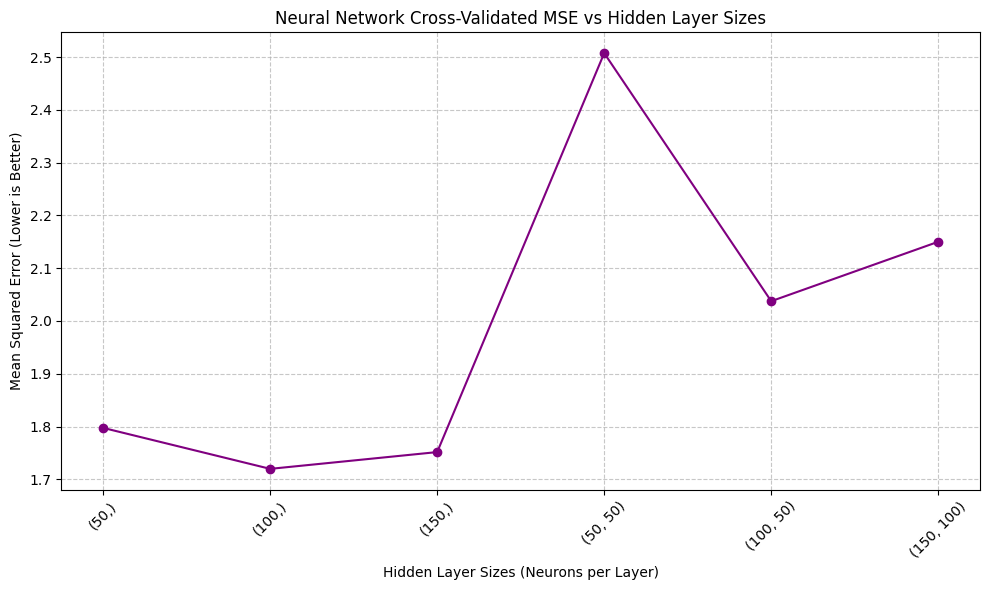

In [ ]:
# Define a list of hidden layer architectures to evaluate. 
# Single tuples like (50,) mean one layer with 50 neurons.
# Double tuples like (50, 50) mean two layers, each with 50 neurons.
sizes_layer_options = [(50,), (100,), (150,), (50, 50), (100, 50), (150, 100)]

# Initialise a list to store the Cross-Validated MSE for each architecture
nn_mse_scores = []

# Initialise variables to keep track of the best performing architecture
best_mse = float('inf')
best_layer_size = None

# Iterate through each architecture in the options list
for size in sizes_layer_options:
    # Initialise the Neural Network with the current architecture
    # max_iter is kept at 2000 to prevent convergence warnings
    nn_model = MLPRegressor(random_state=44, max_iter=2000, hidden_layer_sizes=size)
    
    # Fit the model to the data
    nn_model.fit(x_train_scaled, y_train_scaled)

    # Perform 5-fold cross-validation to get a MSE estimate
    # scikit-learn returns negative MSE, so it is negated to get positive values
    cv_scores = -cross_val_score(nn_model, x_train_scaled, y_train_scaled, cv=5, scoring='neg_mean_squared_error')
    
    # Calculate the average MSE across the 5 folds and append it to the list
    mean_mse = cv_scores.mean()
    nn_mse_scores.append(mean_mse)

    # Update the "best" tracking variables if the current architecture performs better
    if mean_mse < best_mse:
        best_mse = mean_mse
        best_layer_size = size

# Print the comparison between the baseline default model and the newly optimised model
# Note: The default hidden_layer_sizes in scikit-learn is (100,)
print(f"Original MSE with default layer size: {nn_mean_squared_error.mean()}")
print(f"Best NN Mean Squared Error: {best_mse} with layer size: {best_layer_size}")

# Plot the results to visualise how adding neurons or layers affects the error
plt.figure(figsize=(10, 6))
plt.plot([str(size) for size in sizes_layer_options], nn_mse_scores, marker='o', color='purple')
plt.title('Neural Network Cross-Validated MSE vs Hidden Layer Sizes')
plt.xlabel('Hidden Layer Sizes (Neurons per Layer)')
plt.ylabel('Mean Squared Error (Lower is Better)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

To optimise the neural network model, a search was conducted to evaluate the models structural capacity. Upon evaluating the cross-validated Mean Squared Error, the search revealed that the optimal configuration achieved an error score  identical to the baseline, un-tuned model. This occurred because the grid search mathematically identified (100,), a single hidden layer containing 100 neurons, as the most accurate architecture, which is the exact default parameter inherently used by the library.

Increasing the representational capacity of the network by adding deeper, denser layers (such as the (150, 100) configuration) yielded no benefits. The analysis proves that the baseline architecture of 100 neurons provides the optimal balance between model generalization and mathematical complexity for this problem space.

## Task 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Define the McCormick function, in order to generate the required values
def mccormick_function(s_array):
    x = s_array[0]
    y = s_array[1]
    fitness_score = np.sin(x+y) + (x-y)**2 - 1.5*x + 2.5*y + 1
    return fitness_score

In [ ]:
# Set the number of required solutions to 500
num_required_solutions = 500

# Set the dimensionality of the problem to 2, as the McCormick function is defined for two variables (x and y)
D = 2

# Generate random solutions within the specified bounds of -5 to 5 for both x and y, creating an array of shape (num_required_solutions, D) where each row represents a solution with two variables (x and y)
rad_solutions = np.random.uniform(-5,5, (num_required_solutions, D))

# Initialize an empty list to store the fitness scores for each solution generated
fitness_scores = []

# Iterate through each solution in the generated random solutions, calculate the fitness score using the McCormick function for each solution, and append the calculated fitness score to the list
for solution in rad_solutions:
    fitness = mccormick_function(solution)
    fitness_scores.append(fitness)

In [ ]:
# Create a scatter plot of the random solutions, where the x and y coordinates correspond to the two variables of the solutions, and the color of each point represents the fitness score calculated for that solution using the McCormick function
plt.scatter(rad_solutions[:, 0], rad_solutions[:, 1], c=fitness_scores, cmap='viridis', s=50)
plt.colorbar(label='Fitness Score')
plt.title('Random Solutions Colored by Fitness Score')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Before starting work on the optimisation algorithms, it was necessary to generate a large number of baseline solutions to understand better the multi-dimensional landscape of the McCormick function. To achieve this, a random sample of 500 solutions has been generated using a dimensionality of 2, this representing the x and y coordinates. 

To generate these solutions, an uniform distribution (np.random.uniform) bounded between -5 and 5 was used. By passing these coordinates through the McCormick function, an initial dataset of 500 distinct fitness scores was calculated. These solutions were visualised using a colour-mapped scatter plot, providing immediate insight to the existence of low-fitness peaks and high-fitness valleys present in the data.

In [ ]:
class GMutation:
    def __init__(self,mutation_step_size):
        # The 'step_size' determines how far the mutation can jump. 
        # A smaller step size means fine-tuning; a larger step size means broader exploration.
        self.mutation_step_size = mutation_step_size

    def mutate(self, solution):
        # Create a copy of the parent solution so it is not accidentally overwritten during mutation
        solution_copy = solution.copy()
        # Add random noise drawn from a normal (Gaussian) distribution.
        solution_copy += np.random.normal(loc=0.0, scale=self.mutation_step_size, size=solution_copy.shape)
        return solution_copy

# Hill Climber
def evolve(x, y, function, mutation, compare, A):
    # 1. Mutate the current solution (x) to create a new solution (xp)
    xp = mutation.mutate(x)

    # 2. Evaluate the fitness of the new candidate solution
    yp = function(xp)

    # 3. Selection: Compare the new fitness (yp) against the old fitness (y).
    # If the new solution is NOT worse, it is accepted and updates our current position.
    if not compare(y , yp) :
        x = xp
        y = yp

    # Record in the archive for later visualisation
    A.append(y)

    # Return all values
    return x,y,A, xp, yp

def lessOrEqual(a, b):
    return a <= b

def optimise(D, function, mutation, ngens, compare):

    # Initialise a random starting position within the bounds [-5, 5]
    x = np.random.uniform(-5, 5, D)

    # Calculate the fitness of the starting position
    y = function(x)

    # Store every attempted solution [x_coord, y_coord, fitness] to plot the algorithm's trajectory
    archive = []
    all_solutions = [[x[0], x[1], y]]

    # Loop for the specified number of generations (iterations)
    for gen in range(ngens):
        # Take one step, then log the attempted solution and its fitness
        x, y, archive, xp, yp = evolve(x, y, function, mutation, compare, archive)
        all_solutions.append([xp[0], xp[1], yp])

    return x,y,archive, np.array(all_solutions)

# Evolutionary Algorithm
def evolve_pop(parents, parent_fitness, function, mutation):
    # Every parent in the population generates one child via Gaussian mutation
    children = np.array([mutation.mutate(parent) for parent in parents])
    
    # Calculate the fitness for every new child
    child_fitness = np.array([function(child) for child in children])

    # Pool the parents and children together into one large array
    combined_list = np.vstack((parents, children))
    combined_fitness = np.concatenate((parent_fitness, child_fitness))

    # Get the indices that would sort the combined population from best
    best_i = np.argsort(combined_fitness)

    # Keep only the top 50% of the combined pool (which equals the original population size).
    size = len(parents)
    new_parents = combined_list[best_i][:size]
    new_parent_fitness = combined_fitness[best_i][:size]

    return new_parents, new_parent_fitness

def optimise_pop(D, function, mutation, ngens, pop_size):
    # Initialise an array of random starting positions (the initial population)
    parents = np.random.uniform(-5, 5, (pop_size, D))
    # Calculate the fitness for the entire initial population
    parent_fitness = np.array([function(parent) for parent in parents])
    archive = []

    # Loop for the specified number of generations
    for gen in range(ngens):
        # Evolve the entire population by one generation
        parents, parent_fitness = evolve_pop(parents, parent_fitness, function, mutation)
        # Since the population is always sorted in evolve_pop, index 0 is always the absolute best solution
        archive.append(parent_fitness[0])

    return parents[0], parent_fitness[0], archive, parents, parent_fitness

The first algorithm written was a Hill Climbing algorithm. The mutation operator has been designed into a Python class (GMutation), as documented in the modules labs. This class utilises a Gaussian distribution (np.random.normal) centered at zero to mathematically find a given solution. By making the mutation step size a simple configurable parameter, the algorithm's scope and reach can be easily tuned. 

The Hill Climber acts as a strict heuristic algorithm. Within the evolve function, a child solution is generated and then evaluated. The algorithm uses a boolean check (lessOrEqual) to strictly dictate movement. If the mutated child possesses a superior (lower) fitness score, the algorithm steps to the new coordinates; if it is worse, the step is rejected. 

To aid in visual data analysis later, the loop was configured to record, not only the accepted steps, but also rejected mutation attempts (xp and yp), allowing for a complete visualisation of the algorithms search behaviour later in the tasks.

Further, to test and overcome the hill climbers inherent vulnerability of getting stuck in shallow, sub-optimal valleys, a population-based Evolutionary Algorithm (EA) was developed. A major design choice behind this algorithm is that the code reuses the exact same GMutation operator and objective function as the Hill Climber. Instead of processing a single agent, it simultaneously mutates an entire array of parent solutions to generate children. Using np.vstack and np.concatenate, the parents and children are pooled together. Finally, np.argsort is utilised to mathematically rank the combined population, allowing the algorithm to seamlessly slice the array and retain only the top 50% for the next generation. 

In [ ]:
# Set the total number of iterations/generations for the algorithms to run.
ngens = 400

# Initialize the Gaussian mutation operator. 
# A step size of 0.1 was chosen to allow for precise, high-resolution steps without accidentally overstepping over the optimal solution.
mutation = GMutation(mutation_step_size=0.1)

# Execute the single-agent Hill Climber.
h_best_sol, h_best_fit, h_fitness_history, h_all_solutions = optimise(D, function=mccormick_function, mutation=mutation, ngens=ngens, compare=lessOrEqual)

# Print the final results for the Hill Climber
print(f"Hill Climber - Best solution: {h_best_sol}, Best fitness: {h_best_fit}")

# Execute the population-based Evolutionary Algorithm.
e_best_sol, e_best_fit, e_fitness_history, e_final, e_final_fitness = optimise_pop(D, function=mccormick_function, mutation=mutation, ngens=ngens, pop_size=50)

# Print the final results for the Evolutionary Algorithm
print(f"Evolutionary Algorithm - Best solution: {e_best_sol}, Best fitness: {e_best_fit}")

With both optimisation algorithms established, they were deployed against the McCormick function under identically controlled conditions to ensure a scientifically fair comparison. A shared mutation step size of 0.1 and a runtime of 400 iterations/generations were deliberately selected.

During early testing, it was discovered that larger step sizes (e.g., 0.5) caused the algorithms to take massive, chaotic leaps, occasionally vaulting completely over the true mathematical minimum. By reducing the mutation_step_size to 0.1 and extending the runtime to 400, the algorithms were forced to take finer, higher-resolution steps. This parameter tuning was essential; it provided the algorithms with enough exploratory precision to map the solutions in detail, while granting them enough iterations to fully converge at the bottom of their valleys.

In [ ]:
def results_plot(h_fitness_history, h_all_solutions, e_fitness_history, e_final, e_final_fitness):
    # Direct Overlay Plot: Comparing the descent profiles
    plt.figure(figsize=(10, 5))
    plt.plot(h_fitness_history, label='Hill Climber', color='blue', linewidth=2)
    plt.plot(e_fitness_history, label='Evolutionary Algorithm (Pop=50)', color='red', linewidth=2)
    plt.title('Algorithm Comparison: Fitness over Runtime')
    plt.xlabel('Iterations / Generations')
    plt.ylabel('Best Fitness Score (Lower is Better)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    fig, axis = plt.subplots(2, 2, figsize=(16, 5))
    plt.subplots_adjust(hspace=0.5, wspace=0.5)

    scatter1 = axis[0,0].scatter(h_all_solutions[:, 0], h_all_solutions[:, 1], c=h_all_solutions[:, 2], cmap='viridis')
    axis[0, 0].set_title('Hill Climbing Visited Solutions')
    axis[0, 0].set_xlabel('X')
    axis[0, 0].set_ylabel('Y')

    axis[0, 1].plot(h_fitness_history, color='blue')
    axis[0, 1].set_title('Hill Climber: Fitness over Iterations')
    axis[0, 1].set_xlabel('Iteration')
    axis[0, 1].set_ylabel('Best Fitness')

    scatter2 = axis[1, 0].scatter(e_final[:, 0], e_final[:, 1], c=e_final_fitness, cmap='viridis')
    fig.colorbar(scatter2, ax=axis[1, 0], label='Fitness')
    axis[1, 0].set_title('Evolutionary Algorithm Final Population')
    axis[1, 0].set_xlabel('X')
    axis[1, 0].set_ylabel('Y')

    axis[1, 1].plot(e_fitness_history, color='red')
    axis[1, 1].set_title('Evolutionary Algorithm: Best Fitness over Generations')
    axis[1, 1].set_xlabel('Generation')
    axis[1, 1].set_ylabel('Best Fitness')

    plt.show()

results_plot(h_fitness_history, h_all_solutions, e_fitness_history, e_final, e_final_fitness)

One of the strict requirements of this module was the separation of optimisation and visualisation code. Furthermore to this,integrating matplotlib rendering calls directly inside an active evolutionary loop is well known to severely bottleneck  performance. 

In order to satisfy these requirements, a dedicated, standalone visualisaton function has been created, separate to the other code. The optimisation algorithms were strictly limited to mathematical operations, returning pure data arrays upon completion, and only after both algorithms had fully terminated was this raw data passed into the decoupled results_plot function. This modular architecture not only improved execution speed, but also allowed for rapid iteration on the graph designs without needing to repeatedly re-run the computationally heavy optimisation algorithms.

The visualisation function was designed to output distinct graphical figures to evaluate the algorithms' behaviors comprehensively:
- Direct Overlay = By overlaying the Hill Climber (blue) and Evolutionary Algorithm (red) on the same axes, the large difference in their convergence profiles becomes immediately apparent. The Evolutionary Algorithm's line drops suddenly due to a single generation representing 50 parallel evaluations whereas the Hill Climber represents a single serial attempt.
- Analytical Grid = To provide alternative views, a 2x2 matrix of subplots are shown. The top row isolates the Hill Climber, contrasting its physical trajectory against its temporal progress (the stepped descent of its fitness). The bottom row mirrors this for the Evolutionary Algorithm, visualising how a dispersedcloud of 50 agents mathematically translates into a smoothed descent curve (line plot). 

In [ ]:
runs = 100
h_stable_scores = []
e_stable_scores = []

for run in range(runs):
    h_best_sol, h_best_fit, h_fitness_history, h_all_solutions = optimise(D, function=mccormick_function, mutation=mutation, ngens=ngens, compare=lessOrEqual)
    h_stable_scores.append(h_best_fit)

    e_best_sol, e_best_fit, e_fitness_history, e_final, e_final_fitness = optimise_pop(D, function=mccormick_function, mutation=mutation, ngens=ngens, pop_size=50)
    e_stable_scores.append(e_best_fit)

fig, axis = plt.subplots(1, 2, figsize=(12, 5))
axis[0].scatter(range(runs), h_stable_scores, color='blue', alpha=0.6)
axis[0].set_title('Hill Climber: Best Fitness over 100 Runs')
axis[0].set_xlabel('Run Number')
axis[0].set_ylabel('Best Final Fitness')
axis[0].grid(True, alpha=0.5)

axis[1].scatter(range(runs), e_stable_scores, color='red', alpha=0.6)
axis[1].set_title('Evolutionary Algorithm: Best Fitness over 100 Runs')
axis[1].set_xlabel('Run Number')
axis[1].grid(True, alpha=0.5)

plt.suptitle('Stability Analysis: Best Fitness across Multiple Runs')
plt.show()

Due to both the Hill Climber and the Evolutionary Algorithm relying heavily on random number generation for initial state placements and subsequent mutations, a single execution cannot prove an algorithm's overall effectiveness. The algorithm might experience a lucky initialisation near the global minimum, so to evaluate true reliability, they were executed 100 times. 

For each of the 100 independent runs, only the final best fitness score was recorded. Visualising these distributions side-by-side using scatter plots immediately reveals the contrast in robustness. 

The scatter plot for the Hill Climber demonstrates massive variance, with the final fitness scores visibly stratifying into several distinct horizontal bands across the y-axis. This visually proves that the Hill Climber is exceptionally fragile and highly sensitive to its initial starting conditions.

Conversely, the Evolutionary Algorithm demonstrates good stability. Across the 100 runs, the vast majority of its terminal scores form a solid, consistent line at the absolute mathematical minimum of the McCormick function. 

This shows definitively that the population-based mechanics, specifically the spacial distribution of 50 initial agents, sucessfully deter the algorithm against variance based on poor starting positions.